# Credit Risk Modelling 

In this notebook, I am using the (German Credit dataset) to build a simple credit risk model and see how it impacts lending decisions.
The goal is not just accuracy. I want to see how model decisions affect financial outcomes, especially when I adjust the threshold.

# Setup
Importing the main libraries needed for data handling, modelling, and evaluation.

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

## Load and prepare data
Load the dataset, review it quickly, and get it ready for modelling.

In [3]:
# load the data and preprocess

In [4]:
df = pd.read_csv('GermanCredit.csv')

In [5]:
df["Class"]

0      Good
1       Bad
2      Good
3      Good
4       Bad
       ... 
995    Good
996    Good
997    Good
998     Bad
999    Good
Name: Class, Length: 1000, dtype: object

In [6]:
# Encode the target variable 'Class'

In [7]:
label_encoder = LabelEncoder()
df['Target'] = label_encoder.fit_transform(df['Class'])

In [8]:
df

,Duration,Amount,InstallmentRatePercentage,ResidenceDuration,Age,NumberExistingCredits,NumberPeopleMaintenance,Telephone,ForeignWorker,Class,...,OtherInstallmentPlans.Stores,OtherInstallmentPlans.None,Housing.Rent,Housing.Own,Housing.ForFree,Job.UnemployedUnskilled,Job.UnskilledResident,Job.SkilledEmployee,Job.Management.SelfEmp.HighlyQualified,Target
0,6,1169,4,4,67,2,1,0,1,Good,...,0,1,0,1,0,0,0,1,0,1
1,48,5951,2,2,22,1,1,1,1,Bad,...,0,1,0,1,0,0,0,1,0,0
2,12,2096,2,3,49,1,2,1,1,Good,...,0,1,0,1,0,0,1,0,0,1
3,42,7882,2,4,45,1,2,1,1,Good,...,0,1,0,0,1,0,0,1,0,1
4,24,4870,3,4,53,2,2,1,1,Bad,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,1,1,Good,...,0,1,0,1,0,0,1,0,0,1
996,30,3857,4,4,40,1,1,0,1,Good,...,0,1,0,1,0,0,0,0,1,1
997,12,804,4,4,38,1,1,1,1,Good,...,0,1,0,1,0,0,0,1,0,1
998,45,1845,4,4,23,1,1,0,1,Bad,...,0,1,0,0,1,0,0,1,0,0


In [9]:
X = df.drop(['Class', 'Target'], axis=1)
y = df['Target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
#standardize scalers

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline model (Logistic Regression)
Start with a simple model to get a baseline before going deeper.

In [13]:
# train the logistic model & # Predict probabilities on the test set

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [15]:
y_prob

array([0.57897817, 0.44455885, 0.28775521, 0.67336047, 0.96547835,
       0.56039776, 0.95566597, 0.43589704, 0.97248055, 0.95849577,
       0.85385452, 0.4063706 , 0.89596901, 0.09296641, 0.0988168 ,
       0.7050301 , 0.9727212 , 0.97402487, 0.43444845, 0.67720499,
       0.96312957, 0.33708498, 0.93575205, 0.98771859, 0.98521413,
       0.31615129, 0.49474469, 0.20786211, 0.94628642, 0.82406009,
       0.91079178, 0.86058373, 0.73606106, 0.76650096, 0.81448952,
       0.75961826, 0.3644611 , 0.84771073, 0.91858966, 0.18679296,
       0.70417477, 0.95974677, 0.72904161, 0.90231314, 0.96054693,
       0.86328375, 0.2245562 , 0.61919061, 0.79159793, 0.898969  ,
       0.34005411, 0.96709139, 0.63129908, 0.21222376, 0.95852106,
       0.74409268, 0.52753438, 0.2885575 , 0.12487658, 0.73149546,
       0.92997189, 0.32994406, 0.56466265, 0.99854083, 0.69809252,
       0.7770503 , 0.92177181, 0.29841026, 0.73132129, 0.90008542,
       0.63228624, 0.89408008, 0.85884058, 0.5013757 , 0.72578

## Initial evaluation
Check how the model performs using standard metrics and the confusion matrix.

In [16]:
# Evaluate at the default threshold of 0.3

In [17]:
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

In [18]:
y_pred

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1])

In [19]:
#Evalute models performance

In [20]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

In [21]:
print(f"=== Evaluation at Threshold = {threshold:.2f} ===")
print("Confusion Matrix:")
print(cm)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

=== Evaluation at Threshold = 0.30 ===
Confusion Matrix:
[[ 20  39]
 [  7 134]]
Accuracy: 0.7700
Classification Report:
              precision    recall  f1-score   support

         Bad       0.74      0.34      0.47        59
        Good       0.77      0.95      0.85       141

    accuracy                           0.77       200
   macro avg       0.76      0.64      0.66       200
weighted avg       0.76      0.77      0.74       200



## Financial impact (value matrix)
Here I translate model results into financial terms so it reflects real lending decisions.

### Assumptions
I assume an average loan of 1000.
Loss = 20% (200) for bad loans approved.
No loss for correct decisions.
No reserve for good loans that are rejected.

In [22]:
# Define the value matrix for the loan scenario
cost_matrix = np.array([
    [0, -200],  # TN loss, FP loss
    [0,   0]   # FN loss, TP loss
])

In [23]:
#create value matrix

In [24]:
#calculate the cost matrix

In [25]:
cost_matrix

array([[   0, -200],
       [   0,    0]])

In [26]:
cost_matrix = cm * cost_matrix

In [27]:
cost_matrix, cm

(array([[    0, -7800],
        [    0,     0]]),
 array([[ 20,  39],
        [  7, 134]]))

In [28]:
#plot the confusion matrix
#Plot the cost matrix side by side with the confusion matrix.

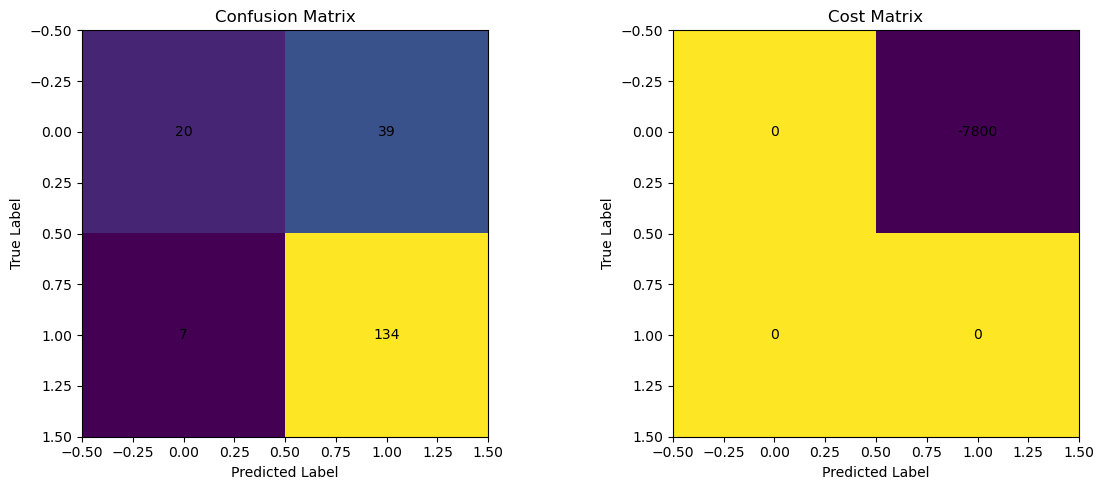

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cm, interpolation='nearest')
for (i, j), val in np.ndenumerate(cm):
    axes[0].text(j, i, val, ha='center', va='center')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

axes[1].imshow(cost_matrix, interpolation='nearest')
for (i, j), val in np.ndenumerate(cost_matrix):
    axes[1].text(j, i, val, ha='center', va='center')
axes[1].set_title('Cost Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Threshold analysis
Instead of using one cutoff, I test multiple thresholds to see how results change.

### Why this matters
The threshold changes the balance between approving risky vs safe clients.
This directly impacts cost.

In [30]:
#8 to 11

In [31]:
# --- Value matrix parameters ---
loan_amount = 1000
loss_rate   = 0.20
value_matrix = np.array([[0, loan_amount*loss_rate],[0, 0]])

### Cost matrix
I combine the confusion matrix with the value assumptions to estimate financial impact.
This shows where the real cost is coming from.

### Optimal threshold
Pick the threshold that minimizes financial impact.
Then check the confusion matrix and metrics at that point.

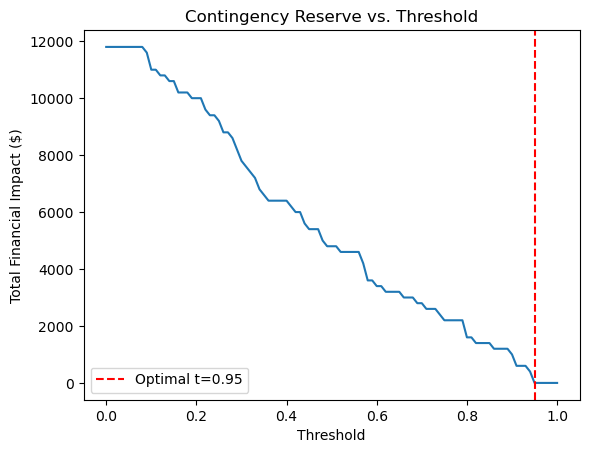

Optimal threshold: 0.95
Minimum Contingency Reserve: $0

Confusion Matrix at Optimal Threshold:
[[ 59   0]
 [110  31]]

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

         Bad       0.35      1.00      0.52        59
        Good       1.00      0.22      0.36       141

    accuracy                           0.45       200
   macro avg       0.67      0.61      0.44       200
weighted avg       0.81      0.45      0.41       200



In [32]:
# --- Function to compute total impact ---
def total_impact(threshold):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    cost = (cm * value_matrix).sum()
    return cost

# --- Evaluate across thresholds ---
thresholds = np.linspace(0, 1, 101)
impacts = [total_impact(t) for t in thresholds]

# --- Find optimal threshold ---
min_idx = int(np.argmin(impacts))
optimal_threshold = thresholds[min_idx]
optimal_impact = impacts[min_idx]

# --- Metrics at optimal threshold ---
y_pred_opt = (y_prob >= optimal_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt, labels=[0,1])
report_opt = classification_report(y_test, y_pred_opt, target_names=label_encoder.classes_)

# --- Plot Impact vs Threshold ---
plt.figure()
plt.plot(thresholds, impacts)
plt.axvline(optimal_threshold, color='red', linestyle='--',
            label=f'Optimal t={optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Financial Impact ($)')
plt.title('Contingency Reserve vs. Threshold')
plt.legend()
plt.show()

# --- Print results ---
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Minimum Contingency Reserve: ${optimal_impact:.0f}\n")
print("Confusion Matrix at Optimal Threshold:")
print(cm_opt)
print("\nClassification Report at Optimal Threshold:")
print(report_opt)

## Updated value matrix and revised financial view
After identifying the threshold behavior, I recalculate the financial impact using the updated assumptions in the notebook. This helps confirm whether the model decisions improve once the business value framework changes.

In [33]:
#12

In [34]:
# New value matrix with profit/opportunity cost

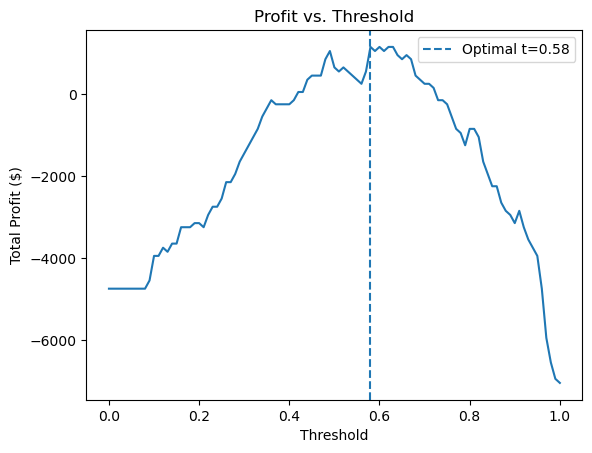

Optimal threshold: 0.58
Maximum Total Profit: $1150

Confusion Matrix at Optimal Threshold:
[[ 41  18]
 [ 23 118]]

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

         Bad       0.64      0.69      0.67        59
        Good       0.87      0.84      0.85       141

    accuracy                           0.80       200
   macro avg       0.75      0.77      0.76       200
weighted avg       0.80      0.80      0.80       200



In [35]:
# TN=0, FP=-200 (loss), FN=-50 (missed profit), TP=+50 (profit)
value_matrix = np.array([
    [   0, -200],
    [  -50,   50]
])

# --- Function to compute total profit at a threshold ---
def total_profit(threshold):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    return (cm * value_matrix).sum()

# --- Evaluate profit across thresholds ---
thresholds = np.linspace(0, 1, 101)
profits = [total_profit(t) for t in thresholds]

# --- Find optimal threshold (max profit) ---
best_idx = int(np.argmax(profits))
best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

# --- Metrics at optimal threshold ---
y_pred_best = (y_prob >= best_threshold).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best, labels=[0,1])
report_best = classification_report(y_test, y_pred_best, target_names=label_encoder.classes_)

# --- Plot Profit vs Threshold ---
plt.figure()
plt.plot(thresholds, profits)
plt.axvline(best_threshold, linestyle='--', label=f'Optimal t={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Profit ($)')
plt.title('Profit vs. Threshold')
plt.legend()
plt.show()

# --- Print results ---
print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Maximum Total Profit: ${best_profit:.0f}\n")
print("Confusion Matrix at Optimal Threshold:")
print(cm_best)
print("\nClassification Report at Optimal Threshold:")
print(report_best)

## Additional models
Here I test a few machine learning algorithms like Random Forest, XGBoost, and a Neural Network to compare results.

In [36]:
#XGBoost

In [37]:
# Initialize the model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
 
# Fit the model to the training data
xgb_model.fit(X_train, y_train)
 
# Predict on the test data
y_pred = xgb_model.predict(X_test)
 
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
 
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
 
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.79
Confusion Matrix:
 [[ 33  26]
 [ 16 125]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.56      0.61        59
           1       0.83      0.89      0.86       141

    accuracy                           0.79       200
   macro avg       0.75      0.72      0.73       200
weighted avg       0.78      0.79      0.78       200



C:\Users\kelvi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:33:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
# Random Forest Tree with Cross validation and grid search

In [39]:
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_split':[2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# 4. Evaluate the best‐found model
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

cm   = confusion_matrix(y_test, y_pred, labels=[0,1])
acc  = accuracy_score(    y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print("Best Hyperparameters:", grid.best_params_)
print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification Report:\n", report)

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Confusion Matrix:
 [[ 24  35]
 [  9 132]]

Accuracy: 0.7800

Classification Report:
               precision    recall  f1-score   support

         Bad       0.73      0.41      0.52        59
        Good       0.79      0.94      0.86       141

    accuracy                           0.78       200
   macro avg       0.76      0.67      0.69       200
weighted avg       0.77      0.78      0.76       200



In [40]:
#Neural Networks

In [41]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   - -------------------------------------- 8.9/351.2 MB 47.8 MB/s eta 0:00:08
   -- ------------------------------------- 21.2/351.2 MB 52.6 MB/s eta 0:00:07
   --- ------------------------------------ 32.2/351.2 MB 52.2 MB/s eta 0:00:07
   ---- ----------------------------------- 43.8/351.2 MB 52.5 MB/s eta 0:00:06
   ----- ---------------------------------- 51.6/351.2 MB 50.7 MB/s eta 0:00:06
   ------ --------------------------------- 59.0/351.2 MB 47.1 MB/s eta 0:00:07
   -------- ------------------------------- 70.8/351.2 MB 48.6 MB/s eta 0:00:06
   --------- ------------------------------ 83.9/351.2 MB 50.3 MB/s eta 0:00:06
   ---------- ----------------------------- 94.1/351.2 MB 50.3 MB/s eta 0:00:06
   ----------- --------------------------- 102.2/351.2 MB 49.3 MB/s eta 0:00:06
   ------------ -------------------------- 113.8/351.2 MB 49.8 MB/s eta 0:00:05
   ------------- ------------------------- 123.5/3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [43]:
# 2) Define & compile the NN
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# 3) Train
model.fit(X_train_scaled, y_train, 
          epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# 4) Predict & evaluate
y_prob_nn = model.predict(X_test_scaled).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

cm_nn     = confusion_matrix(y_test, y_pred_nn, labels=[0,1])
acc_nn    = accuracy_score(y_test, y_pred_nn)
report_nn = classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_)

print("Neural Network Confusion Matrix:\n", cm_nn)
print(f"\nNeural Network Accuracy: {acc_nn:.4f}")
print("\nNeural Network Classification Report:\n", report_nn)

Epoch 1/30


C:\Users\kelvi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6694 - loss: 0.6478 - val_accuracy: 0.7000 - val_loss: 0.5944
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7361 - loss: 0.5353 - val_accuracy: 0.7875 - val_loss: 0.5420
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.4812 - val_accuracy: 0.7500 - val_loss: 0.5387
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.4459 - val_accuracy: 0.7750 - val_loss: 0.5216
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8181 - loss: 0.4186 - val_accuracy: 0.7750 - val_loss: 0.5291
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8264 - loss: 0.3960 - val_accuracy: 0.7750 - val_loss: 0.5421
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8375 - loss: 0.3760 - val_accuracy: 0.7500 - val_loss: 0.5519
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8514 - loss: 0.3600 - val_accuracy: 0.7750 - val_loss: 0.5535
Epo

## Final thoughts
The main takeaway is that accuracy alone is not enough.
Threshold and financial impact matter more in a real lending setup.